# AIC YOLO11n Pose Training

Notebook for validating the exported Ultralytics pose dataset in this repo and training `yolo11n-pose.pt` against it.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
DATA_DIR = ROOT / "data"
IMAGES_DIR = DATA_DIR / "images" / "train"
LABELS_LINK = DATA_DIR / "labels"

print(f"Python executable: {sys.executable}")
print(f"Repo root: {ROOT}")
print(f"Dataset sync script: {ROOT / 'sync_dataset.py'}")
print(f"Expected YOLO PNG images dir: {IMAGES_DIR}")
print(f"Labels link path: {LABELS_LINK}")

Python executable: /home/oseekero/miniconda3/envs/gpu_env/bin/python
Repo root: /home/oseekero/Downloads/aic_train/aic_pose_model
Dataset sync script: /home/oseekero/Downloads/aic_train/aic_pose_model/sync_dataset.py
Expected YOLO PNG images dir: /home/oseekero/Downloads/aic_train/aic_pose_model/data/images/train
Labels link path: /home/oseekero/Downloads/aic_train/aic_pose_model/data/labels


In [2]:
import importlib

required_imports = {
    "torch": "torch",
    "torchvision": "torchvision",
    "ultralytics": "ultralytics",
    "yaml": "pyyaml",
}

problems = []
for module_name, package_name in required_imports.items():
    try:
        importlib.import_module(module_name)
    except Exception as exc:
        problems.append((package_name, f"{type(exc).__name__}: {exc}"))

try:
    import cv2  # noqa: F401
except Exception as exc:
    problems.append(("opencv-python-headless", f"{type(exc).__name__}: {exc}"))

if problems:
    print("Missing or broken dependencies in gpu_env:")
    for package_name, message in problems:
        print(f"- {package_name}: {message}")
    print()
    print("Recommended installs in gpu_env:")
    print(f"{sys.executable} -m pip install pyyaml ultralytics opencv-python-headless")
    print(f"{sys.executable} -m pip install torch torchvision")
    print("If torch fails with missing CUDA .so files, free disk space and reinstall the GPU torch stack in gpu_env.")
else:
    print("All required imports are available in gpu_env.")

All required imports are available in gpu_env.


In [3]:
from collections import Counter
from PIL import Image
import sync_dataset

sync_dataset.main()

train_lines = [line.strip() for line in (ROOT / "train.txt").read_text().splitlines() if line.strip()]
image_paths = [ROOT / line for line in train_lines]
label_paths = [ROOT / "labels" / "train" / Path(line).relative_to("data/images/train") for line in train_lines]
label_paths = [path.with_suffix(".txt") for path in label_paths]

class_counts = Counter()
kp_counts = Counter()
for label_file in label_paths:
    for raw_line in label_file.read_text().splitlines():
        line = raw_line.strip()
        if not line:
            continue
        values = line.split()
        class_counts[int(values[0])] += 1
        kp_counts[(len(values) - 5) // 3] += 1

image_stems = {path.stem for path in image_paths}
label_stems = {path.stem for path in label_paths}

print(f"Images: {len(image_paths)}")
print(f"Labels: {len(label_paths)}")
print(f"Class counts: {dict(class_counts)}")
print(f"Keypoints per object: {dict(kp_counts)}")
print(f"Missing labels for images: {len(image_stems - label_stems)}")
print(f"Missing images for labels: {len(label_stems - image_stems)}")
print("train.txt regenerated from the converted PNG dataset.")

subjects: ['Abi', 'Nik', 'Rag', 'Vam']
source images: 322
converted png images: 322
train images: 257
val images: 65
class counts: {0: 199, 1: 123}
keypoints per object: {17: 322}
wrote: /home/oseekero/Downloads/aic_train/aic_pose_model/train.txt
wrote: /home/oseekero/Downloads/aic_train/aic_pose_model/val.txt
Images: 257
Labels: 257
Class counts: {0: 159, 1: 98}
Keypoints per object: {17: 257}
Missing labels for images: 0
Missing images for labels: 0
train.txt regenerated from the converted PNG dataset.


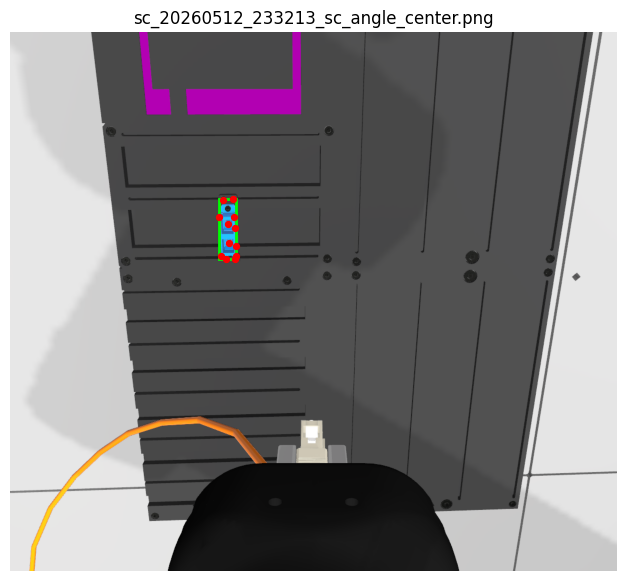

In [4]:
import random
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Rectangle

if not image_paths:
    raise RuntimeError("image_paths is empty. Run the dataset validation cell first.")

sample_path = random.choice(image_paths)
label_path = ROOT / "labels" / "train" / sample_path.relative_to(ROOT / "data" / "images" / "train")
label_path = label_path.with_suffix(".txt")

with Image.open(sample_path) as image:
    width, height = image.size
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(image)
    ax.set_title(sample_path.name)

    for raw_line in label_path.read_text().splitlines():
        values = [float(value) for value in raw_line.split()]
        _, cx, cy, bw, bh, *keypoints = values
        x0 = (cx - bw / 2.0) * width
        y0 = (cy - bh / 2.0) * height
        rect = Rectangle((x0, y0), bw * width, bh * height, fill=False, color="lime", linewidth=2)
        ax.add_patch(rect)
        for idx in range(0, len(keypoints), 3):
            xk, yk, vk = keypoints[idx:idx + 3]
            if int(vk) > 0:
                ax.scatter(xk * width, yk * height, s=18, c="red")

    ax.axis("off")
    plt.show()

In [5]:
MODEL_NAME = "yolo11n-pose.pt"
EPOCHS = 100
IMAGE_SIZE = 1024
BATCH = 8
RUN_NAME = "yolo11n_pose_aic"
PROJECT_DIR = ROOT / "runs"

In [6]:
import torch
from ultralytics import YOLO

device = 0 if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    print(f"Training device: cuda:0 ({torch.cuda.get_device_name(0)})")
else:
    print("Training device: cpu")

model = YOLO(MODEL_NAME)
results = model.train(
    data=str(ROOT / "data.yaml"),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH,
    device=device,
    project=str(PROJECT_DIR),
    name=RUN_NAME,
    exist_ok=True,
)
results

Training device: cpu
Ultralytics 8.4.50 🚀 Python-3.10.19 torch-2.9.1+cu128 CPU (Intel Core i7-9750H 2.60GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/oseekero/Downloads/aic_train/aic_pose_model/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_pose_aic, nbs=64, nms=False, opset

: 

In [ ]:
metrics = model.val(data=str(ROOT / "data.yaml"), device=device)
metrics

## Inference — Port Detection Visualizer

Upload any image (or paste a path) and the trained model will predict bounding boxes, keypoints, and port class.  
Green = SC_SKL (class 0), Blue = SPF_SKL (class 1).

In [ ]:
"""
Port detection inference cell.

Usage
-----
1. Set IMAGE_PATH to any image file on disk (PNG / JPG / PPM).
   Or leave it as None and an ipywidgets file-upload button appears.
2. Run the cell.
3. The annotated image is displayed below with bounding boxes,
   per-keypoint confidence scores, and insertion-axis arrow.
"""
from pathlib import Path
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from PIL import Image as PILImage
from ultralytics import YOLO

# ── Config ────────────────────────────────────────────────────────────────────
IMAGE_PATH  = None          # e.g. Path("data/images/train/Abi/sc/sc_0001.png")
CONF_THRESH = 0.25          # minimum confidence to display
MODEL_PATH  = (
    ROOT / "aic_output" / "best.pt"
    if (ROOT / "aic_output" / "best.pt").is_file()
    else ROOT / "runs" / "yolo11n_pose_aic" / "weights" / "best.pt"
)
CLASS_NAMES = {0: "SC_SKL", 1: "SPF_SKL"}
CLASS_COLORS = {0: "#00e676", 1: "#448aff"}   # green / blue
KP_CONF_MIN = 0.3

print(f"Model: {MODEL_PATH}")
assert MODEL_PATH.is_file(), f"Model not found at {MODEL_PATH}. Train first."
model = YOLO(str(MODEL_PATH))
print(f"Model loaded — classes: {CLASS_NAMES}")

# ── Image source ──────────────────────────────────────────────────────────────
img_pil = None

if IMAGE_PATH is not None:
    img_pil = PILImage.open(IMAGE_PATH).convert("RGB")
    print(f"Loaded: {IMAGE_PATH}")
else:
    try:
        import ipywidgets as widgets
        from IPython.display import display

        uploader = widgets.FileUpload(accept="image/*", multiple=False, description="Upload image")
        display(uploader)

        def on_upload(change):
            global img_pil
            uploaded = list(uploader.value.values())[0]
            img_pil = PILImage.open(io.BytesIO(uploaded["content"])).convert("RGB")
            print(f"Uploaded: {uploaded['metadata']['name']}  ({img_pil.size[0]}×{img_pil.size[1]})")
            run_inference(img_pil)

        uploader.observe(on_upload, names="value")
        print("Select an image with the button above, or set IMAGE_PATH to a file path and re-run.")

    except ImportError:
        raise RuntimeError(
            "ipywidgets is not installed. Set IMAGE_PATH to a file path instead."
        )

# ── Inference + visualisation ─────────────────────────────────────────────────
def run_inference(pil_img: PILImage.Image):
    img_np = np.array(pil_img)
    results = model(img_np, conf=CONF_THRESH, verbose=False)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img_np)
    ax.set_title(
        f"YOLO-pose inference   conf_thresh={CONF_THRESH}   "
        f"{'GPU' if __import__('torch').cuda.is_available() else 'CPU'}",
        fontsize=11,
    )

    for r in results:
        if r.boxes is None:
            continue
        boxes    = r.boxes.xywh.cpu().numpy()          # (N,4) cx cy w h  — pixels
        confs    = r.boxes.conf.cpu().numpy()
        classes  = r.boxes.cls.cpu().numpy().astype(int)
        kp_xy    = r.keypoints.xy.cpu().numpy()         # (N,17,2)
        kp_conf  = (
            r.keypoints.conf.cpu().numpy()
            if r.keypoints.conf is not None
            else np.ones((len(boxes), 17))
        )

        for i, (box, conf, cls_id) in enumerate(zip(boxes, confs, classes)):
            cx, cy, bw, bh = box
            color = CLASS_COLORS.get(cls_id, "#ff1744")
            cls_name = CLASS_NAMES.get(cls_id, f"cls{cls_id}")

            # Bounding box
            rect = mpatches.FancyBboxPatch(
                (cx - bw / 2, cy - bh / 2), bw, bh,
                boxstyle="round,pad=2", linewidth=2,
                edgecolor=color, facecolor="none",
            )
            ax.add_patch(rect)

            # Label
            ax.text(
                cx - bw / 2, cy - bh / 2 - 5,
                f"{cls_name}  {conf:.2f}",
                color="white", fontsize=9, fontweight="bold",
                bbox=dict(facecolor=color, alpha=0.75, pad=2, linewidth=0),
            )

            # Keypoints
            kps   = kp_xy[i]    # (17,2)
            kconfs = kp_conf[i]  # (17,)
            visible = kconfs > KP_CONF_MIN
            if visible.any():
                ax.scatter(
                    kps[visible, 0], kps[visible, 1],
                    c=color, s=30, zorder=5, linewidths=0.5,
                    edgecolors="white",
                )
                # Centroid arrow (approximate insertion direction)
                cx_kp = kps[visible, 0].mean()
                cy_kp = kps[visible, 1].mean()
                ax.annotate(
                    "", xy=(cx_kp, cy_kp - 20), xytext=(cx_kp, cy_kp),
                    arrowprops=dict(arrowstyle="->", color=color, lw=2),
                )

            # Per-keypoint confidence bar inside box
            kp_text = "  ".join(
                f"kp{j}:{kc:.2f}" for j, kc in enumerate(kconfs) if kc > KP_CONF_MIN
            )
            if kp_text:
                ax.text(
                    cx - bw / 2, cy + bh / 2 + 8, kp_text,
                    color=color, fontsize=6,
                )

    legend = [
        mpatches.Patch(color=CLASS_COLORS[0], label="SC_SKL"),
        mpatches.Patch(color=CLASS_COLORS[1], label="SPF_SKL"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=9)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    # Text summary
    for r in results:
        if r.boxes is None:
            continue
        for i in range(len(r.boxes)):
            cls_id   = int(r.boxes.cls[i])
            conf_val = float(r.boxes.conf[i])
            box_px   = r.boxes.xywh[i].cpu().numpy()
            n_vis    = int((r.keypoints.conf[i] > KP_CONF_MIN).sum()) if r.keypoints.conf is not None else "?"
            print(
                f"  [{i}] {CLASS_NAMES.get(cls_id, cls_id)}  "
                f"conf={conf_val:.3f}  "
                f"bbox_px=(cx={box_px[0]:.0f}, cy={box_px[1]:.0f}, "
                f"w={box_px[2]:.0f}, h={box_px[3]:.0f})  "
                f"visible_kp={n_vis}/17"
            )

if img_pil is not None:
    run_inference(img_pil)